# Homework 1: Thinking About Data

BEE 4850/5850

**Name**:

**ID**:

> **Due Date**
>
> Friday, 2/6/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 2 asks you to load and conduct an exploratory analysis of an
    air quality and health dataset.
-   Problem 3 asks you to visualize and conduct an exploratory analysis
    of a cherry blossom dataset.
-   Problem 4 asks you to explore the impacts of selection biases on
    statistical relationships.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.Registry.update()
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\nicho\OneDrive\Documents\hw01-NickZajac56`
    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\nicho\OneDrive\Documents\hw01-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\OneDrive\Documents\hw01-NickZajac56\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSVFiles # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools

## Problems

### Problem 1 (7 points)

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [3]:
data = DataFrame(load("data/bites.csv")) # load data into DataFrame

# print data variable (semi-colon suppresses echoed output in Julia, which in this case would duplicate the output)
@show data;

data = 43×2 DataFrame
 Row │ group   bites
     │ String  Int64
─────┼───────────────
   1 │ beer       27
   2 │ beer       20
   3 │ beer       21
   4 │ beer       26
   5 │ beer       27
   6 │ beer       31
   7 │ beer       24
   8 │ beer       21
   9 │ beer       20
  10 │ beer       19
  11 │ beer       23
  12 │ beer       24
  13 │ beer       28
  14 │ beer       19
  15 │ beer       24
  16 │ beer       29
  17 │ beer       18
  18 │ beer       20
  19 │ beer       17
  20 │ beer       31
  21 │ beer       20
  22 │ beer       25
  23 │ beer       28
  24 │ beer       21
  25 │ beer       27
  26 │ water      21
  27 │ water      22
  28 │ water      15
  29 │ water      12
  30 │ water      21
  31 │ water      16
  32 │ water      19
  33 │ water      15
  34 │ water      22
  35 │ water      24
  36 │ water      19
  37 │ water      23
  38 │ water      13
  39 │ water      22
  40 │ water      20
  41 │ water      24
  42 │ water      18
  43 │ water      20


How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [4]:
# split data into vectors of bites for each group
beer = data[data.group .== "beer", :bites]
water = data[data.group .== "water", :bites]

observed_difference = mean(beer) - mean(water)
@show observed_difference;

observed_difference = 4.37777777777778


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

#### Problem 1.1

Conduct the above procedure to generate 50,000 simulated datasets under
the skeptic’s hypothesis. Plot a histogram of the results and add a
dashed vertical line to show the experimental difference (if you are
using Julia, feel free to look at the [Making Plots with Julia
tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
on the class website).

#### Problem 1.2

Draw conclusions about the plausibility of the skeptic’s hypothesis that
there is no difference between groups. Feel free to use any quantitative
or qualitative assessments of your simulations and the observed
difference.

### Problem 2 (5 points)

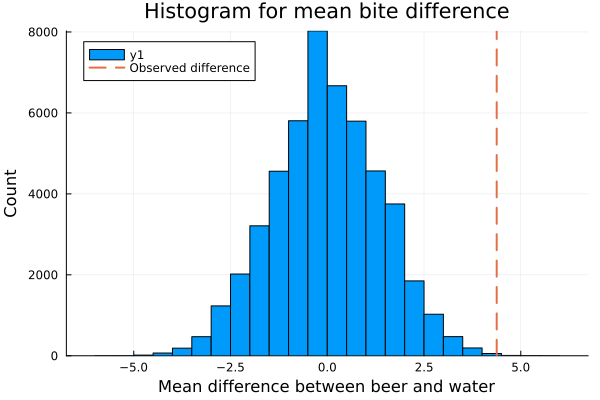

In [ ]:
#problem 1.1

#Set parameters 
mean_beer = mean(data.bites[data.group .== "beer"])
mean_water = mean(data.bites[data.group .== "water"])

diff = mean_beer - mean_water

n = 50000
diffs = zeros(n)

#loop to shuffle datasets testing the skeptic's hypothesis

for i in 1:n
    shuffled_data = shuffle(data.group)  #reorganizes the data and randomizes group association 
                    #to already existing bite counts
    diffs[i] = mean(data.bites[shuffled_data .== "beer"]) -
               mean(data.bites[shuffled_data .== "water"])
end

#plot code

histogram(diffs; bins = 30, xlabel = "Mean difference between beer and water", 
ylabel = "Count", title = "Histogram for mean bite difference")

vline!([diff]; linestyle = :dash, linewidth = 2, label = "Observed difference")

Problem 1.2

Given the 50,000 permutations and then the multiple repeated simulations of said 50,000 permutations, I have drawn the conclusion that the skeptic's hypothesis is not statistically supported.  The data above in the histogram follows a seemingly Gaussian distribution, with a very-defined bell curve shape centered around 0.  The observed original difference was ~4.4, which, as seen in the histogram above, is towards the extreme righthand of the chart where there are a very small set of counts.  Based on the chart above, it appears that there may be a correlation between the liquid consumed and the amount of mosquito bites and that the relationship is statistically significant.  There are very few permutations that had a mean difference as large as the originally calculated one and there is little to no statistical evidence supporting the skeptic's hypothesis.  


#### Problem 2

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))
contains data on the relationship between environmental conditions
(temperature and air quality) and deaths in Chicago from 1987–2000. The
dataset contains the following variables:

1.  The number of non-accidental deaths each day (`deaths`);
2.  The median density over the city of PM10 (large particulate matter)
    particles (`pm10median`);
3.  The median density over the city of PM 2.5 (small particulate
    matter) particles (`pm25median`);
4.  The median concentration of ozone (O\[3\]) (`o3median`);
5.  The median concentration of sulfur dioxide (SO\[2\]) (`so2median`);
6.  The time in days (`time`);
7.  The daily mean temperature (`tmpd`).

#### Problem 2.1

Load the dataset and compute the following summary statistics for each
column (you can do this using built-in functions as available in the
language you are using):

1.  Minimum, 25th percentile, median, 75th percentile, and maximum;
2.  Mean;
3.  Number of missing data entries (`NA`s).

What are the units for the temperatures? Explain why there are so many
negative values for the pollution variables.

#### Problem 2.2

Plot the number of deaths versus the time (convert the time to the
calendar date). Describe any patterns that you see.

#### Problem 2.3

Plot the number of deaths versus the temperature. Describe any patterns
that you see.

#### Problem 2.4

What do you think has a clearer influence on the number of deaths: date
or temperature?

In [6]:
data_chicago = DataFrame(load("data/chicago.csv")) # load data into DataFrame

#establish a dataframe to hold results for each column
results = DataFrame(
    name = String[],
    min = Float64[],
    q25 = Float64[],
    median = Float64[],
    q75 = Float64[],
    max = Float64[],
    mean = Float64[],
    n_missing = Int[]
)

#for loop to go through each of the columns in the dataset
for n_c in names(data_chicago)
    x  = data_chicago[!, n_c]
    col = collect(skipmissing(x))

#push each columns summary statistics to be displayed
    push!(results, (n_c,
        minimum(col),
        quantile(col, 0.25),
        median(col),
        quantile(col, 0.75),
        maximum(col),
        mean(col),
        count(ismissing, x)))
end

results


Row,name,min,q25,median,q75,max,mean,n_missing
,String,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,Column1,1.0,1279.25,2557.5,3835.75,5114.0,2557.5,0
2,death,69.0,105.0,114.0,124.0,411.0,115.419,0
3,pm10median,-37.3761,-13.1082,-3.53906,8.30292,320.725,-0.14639,251
4,pm25median,-16.4264,-6.58841,-1.32584,5.34377,38.1504,0.243053,4387
5,o3median,-24.7794,-10.2319,-3.32586,4.46821,43.6878,-2.17938,0
6,so2median,-8.2061,-2.68935,-1.21826,0.831593,28.9034,-0.636071,27
7,time,-2556.5,-1278.25,0.0,1278.25,2556.5,0.0,0
8,tmpd,-16.0,35.0,51.0,67.0,92.0,50.1933,0


#### Problem 2.1

The units for temperatures are Celsius.

I think that there are so many negative values for the pollution variables due to instrument reading issues and maybe improper calibration.  I actually have extensive work with real-time air monitoring equipment and air sampling analysis (NIOSH 500 Cassettes, Summa Canisters, PUF sampling) and I know that they can be a bit tricky to calibrate, especially in windy environments like Chicago can be.


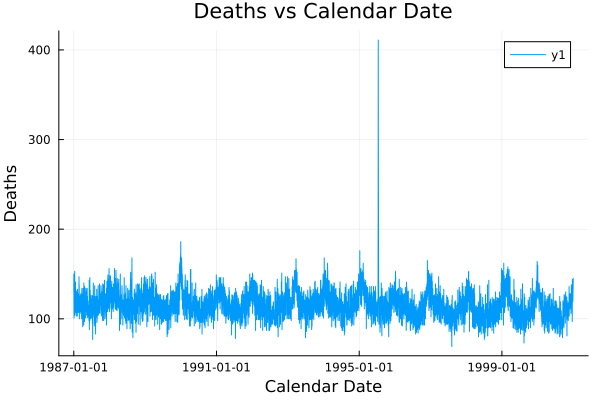

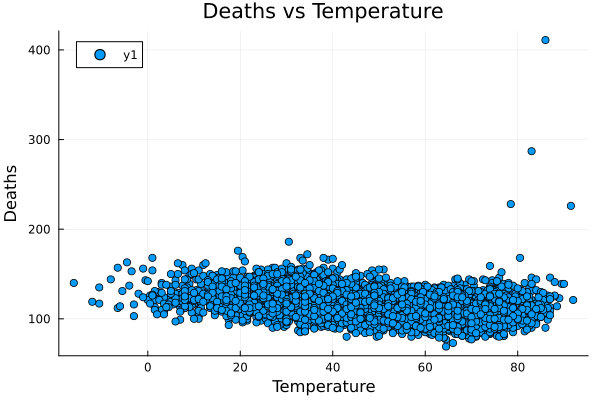

In [ ]:


#Problem 2.2

#date conversion assuming the first entry is on 1/1/1987

#There are 5114 entries in this dataset, which, divided by 365, is almost exactly 14 years.
#This matches up with a start date of 1/1/1987 and an end date of 12/31/2000.
#Therefore, I just created my own date place holder and counted upwards to avoid converting 
#and rounding values that are in the chicago.csv dataset

using Dates

start = Date(1987, 1, 1)
n_cc = nrow(data_chicago)
data_chicago.date = start .+ Day.(0:n_cc-1)

#plot code
p1 = plot(data_chicago.date, data_chicago.death; xlabel = "Calendar Date",  ylabel = "Deaths", 
title = "Deaths vs Calendar Date")

display(p1)


#Problem 2.3


scatter(data_chicago.tmpd, data_chicago.death; xlabel = "Temperature",  ylabel = "Deaths", 
title = "Deaths vs Temperature")


Problem 2.2

There appears to be a noticeable sinusoidal/cylclical pattern between the dates and death.  There appears to be a consistent peak in the winter months and a drop in the summer months, suggesting that there may be a seasonality component.

Problem 2.3

I do not see any apparent patterns between temperature and deaths.  There appears to be a pretty consistent death count with temperatures ranging from 0 degrees to 80 degrees, showing no apparent strong relationship between the two.  At best, there may be an extremely small decreasing trend between deaths as temperature increases, but it would be very slight and would certainly need actual statistical calculations to support.

Problem 2.4

I think that the date appears to have a much clearer influence on the number of deaths than temperature.


### Problem 3 (3 points)

Cherry trees flower in the spring, but the opening of their blossoms
requires warm temperatures and is delayed by cold. As a result, cherry
blossom flowering dates are a good proxy for springtime temperatures.
Due to the importance of cherry blossoms in Japanese culture, we have an
(incomplete) record of full blossom dates going back to around 800 CE,
which was developed by Prof. Yasuyuki Aono and several colleagues[1] and
used for temperature reconstructions.

This blossom date data is provided in `data/kyoto.csv`[2]. The three
columns are

1.  the year (CE),
2.  the numerical day of the year full flowering (*e.g.* Jan. 1 is day
    1, Dec. 31 is day 365 or 366);
3.  the date in the Gregorian calendar (*e.g.* Mar. 15 is 0315).

#### Problem 3.1

Load the data file and produce the following summary statistics for the
day (not the date) of full flowering (you can do this using built-in
functions as available in the language you are using):

1.  Minimum, 25th percentile, median, 75th percentile, and maximum;
2.  Mean;
3.  Number of missing data entries (`NA`s).

Why would it not make sense to calculate these summary statistics for
the date column?

#### Problem 3.2

Plot the day of flowering against the year. Add horizontal lines showing
the mean date of flowering as well as the 25th and 75th percentiles. Do
you see any trends or patterns in the data?

In [ ]:
data_kyoto = DataFrame(load("data/kyoto.csv")) # load data into DataFrame

day = data_kyoto[:,2] #store column data for day of full flowering

day_cleaned = collect(skipmissing(day))  #clean data for missing values

#calculate summary statistics
day_min = minimum(day_cleaned)
day_q25 = quantile(day_cleaned, 0.25)
day_median = median(day_cleaned)
day_q75 = quantile(day_cleaned, 0.75)
day_max = maximum(day_cleaned)
day_mean = mean(day_cleaned)
n_missing = count(ismissing, day)

#print summary statistics
println("Min: ", day_min)
println("Q25: ", day_q25)
println("Median: ", day_median)
println("Q75: ", day_q75)
println("Max: ", day_max)
println("Mean: ", day_mean)
println("Number of NAs: ", n_missing)


Min: 86
Q25: 100.0
Median: 105.0
Q75: 109.0
Max: 124
Mean: 104.54050785973398
Number of NAs: 388


Problem 3.1

It doesn't make sense to calculate summary statistics for the date column because the date column stores its values in the Greogorian calendar format.  Performing  summary statistic calculations on the date column would give nonesense results since the dataset is not truly numeric.  

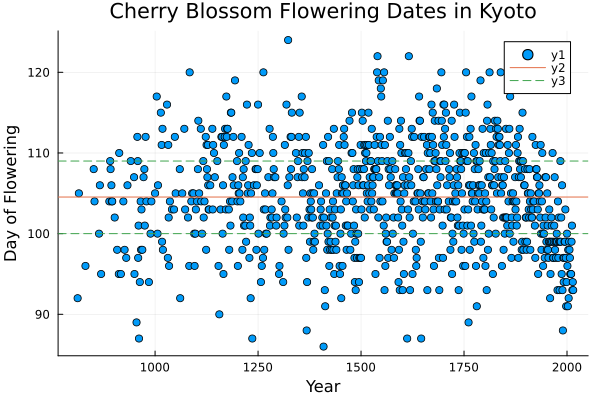

In [ ]:
year = data_kyoto[:,1] #store column data for year of flowering
day = data_kyoto[:,2] #store column data for day of full flowering

day_cleaned = collect(skipmissing(day))  #clean data for missing values
year_cleaned = collect(skipmissing(year))  #clean data for missing values

#Store statistics
avg = mean(day_cleaned)
day_q25 = quantile(day_cleaned, 0.25)
day_q75 = quantile(day_cleaned, 0.75)

#plot code
scatter(year, day, xlabel = "Year", ylabel = "Day of Flowering",
    title = "Cherry Blossom Flowering Dates in Kyoto")

hline!([avg], linestyle = :solid)
hline!([day_q25, day_q75], linestyle = :dash)

Problem 3.2

There appears to be a notable amount of variability between the year and the day of flowering.  There is no pattern to the data that immediately jumps out at me, however, there does appear to be a potential cluster below the 25% quartile mar line around the year 2000 which may indicate a shift towards earlier springs and earlier elevated temperatures.  This still is quite a small sample size among a seemingly pretty variable dataset, so there would need to be a lot more supporting data in order for a stronger conclusion to be made.

### Problem 4 (5 points)

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

#### Problem 4.1

Create a generative model for the grant-selection procedure under the
null assumption of no correlation between rigor and impact. You can
sample rigor and impact scores directly from $\text{Normal}(0, 1)$.
Generate 1,000 datasets using this model and flag the proposals which
would be funded in each. Plot a histogram of the correlations between
rigor and data for (a) the funded proposals and (b) the overall pool.
What do you observe?

#### Problem 4.2

Explain why, when conditioning on selection for funding, there might be
a negative correlation between rigor and impact even if there none
generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.


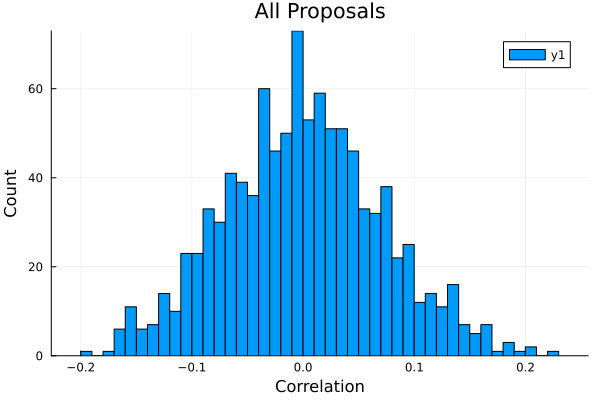

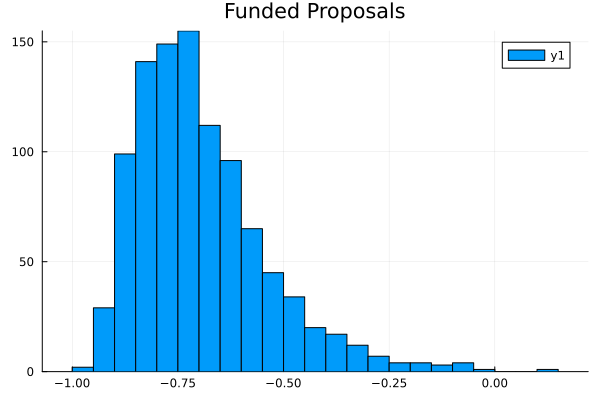

In [14]:
Random.seed!(1) #Random seed 1 since that was what was used in 5750

#set parameters
sims = 1000
props = 200
fund = 0.10
n_fund = Int(props * fund)

corr_fund = zeros(sims)
corr_all = zeros(sims)

#for loop to generate 1000 datasets
for i in 1:sims
    
    #Sample directly from Normal
    rigor = rand(Normal(0,1), props)
    impact = rand(Normal(0,1), props)

    #Calculate total and then sort indices to use for later
    total = rigor .+ impact
    index_fund = sortperm(total; rev = true)[1:n_fund]

    #find correlation utilizing the sorted indices

    corr_all[i] = cor(rigor, impact)
    corr_fund[i] = cor(rigor[index_fund], impact[index_fund])
   

end

#plot code

h1 = histogram(corr_all; bins = 40, xlabel = "Correlation", ylabel = "Count", 
    title = "All Proposals")

display(h1)

histogram(corr_fund, bins = 30, title = "Funded Proposals")



Problem 4.1

I observe that for all proposals, the correlations are centered around zero which substantiates the null hypothesis of no correlation between rigor and impact.  As for the funded proposals, there is a much greater observed negative correlation between rigor and impact, with the most significant bins being found approximately around -0.75.  

Problem 4.2

When conditioning on selection for funding, there may be a negative correlation between rigor and impact even if none generally exists due to the way in which funding is selected.  Since funding is chosen based off of purely adding together rigor and impact, a negative correlation is induced to the selected funds.  For example, if a proposal has a high rigor score, it can have a significantly lower impact score and still be chosen for funding.  That's not an inherent relationship that can be applied to the entire proposal dataset, it's just a result of the selection process.  As see in the "All proposals" chart, the majority of proposals have near 0 correlation, but having the selection be conducted in this manner leads to a negative correlation being observed in solely the funded proposals.  There is essentially now an acceptable tradeoff between rigor and impact due to the selection process which leads to a negative correlation that is not consistent among the dataset.




### Problem 5 (5 points)

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

You have a hypothesis that cheating was not prevalent, and the
proportion of cheaters was no more than 5% of the class; in other words,
we expect 5 “true” cheaters out of a class of 100 students. Our TA is
more jaded and thinks that cheating was more rampant, and that 30% of
the class cheated. The proposed interview procedure is noisy: the
interviewer does not know if an admission means that the student
cheated, or the result of a heads. However, it gives us a
data-generating process that we can model and analyze for consistency
with our hypothesis and that of the TA.

#### Problem 5.1

Derive and code a simulation model for the above interview procedure
given a “true” probability of cheating $p$. Simulate your model (for a
class of 100 students) 50,000 times under your hypothesis of 5%
cheating, the TA’s hypothesis of 30% cheating, and plot the resulting
datasets.

#### Problem 5.2

How many “Yes, I cheated” answers do you think you’d need to see to feel
confident concluding that the TA was right and why? You don’t need to do
a formal analysis, but can reason about this based on your plots.


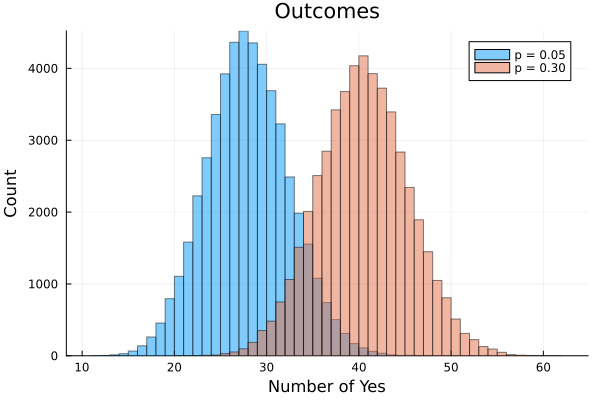

In [ ]:
Random.seed!(1)

#Make a function here for ease of calling

function flip(p; n = 100, sims = 50000)

    #essentially this is what the expected probability of cheating would be
    #with 0.25 coming from the 1/4 chance of tails then heads.  This serves to provide privacy 
    #and plausible deniability to the students who say they are cheating as they can always 
    #claim it is from this instance even if they did in fact cheat.  Then you have 
    #the 0.5*p component which comes from the 50% chance of the first
    #flip being heads and then the p being the cheating probability

    p_yes = 0.5p + 0.25
    rand(Binomial(n, p_yes), sims) #Binomial because this is a binary outcome

end

yes_5 = flip(0.05)
yes_30 = flip(0.30)

#plot code

histogram(yes_5;  bins = 40, alpha = 0.5, label = "p = 0.05", xlabel = "Number of Yes", 
    ylabel = "Count", title = "Outcomes")

histogram!(yes_30; bins = 40, alpha = 0.5, label = "p = 0.30")

Problem 5.2

Personally, I would need about 40-41 "Yes, I cheated" answers to feel confident concluding that the TA was right.  From the plot above, it appears that ~40 is the mode of the p = 0.30 histogram and 40 is very far into the right-hand tail of the p = 0.05 histogram.  Having approximately 40 "Yes, I cheated" answers would make me feel pretty confident that we are beyond the 0.05% cheating hypothesis and are significantly more likely to be in the 30% cheating hypothesis scenario.  Also, the word "confident" really makes me want to be at least near the midpoint of the TA's hypothesis.


## References

[1] Aono, Y., & Omoto, Y. (1993). Variation in the March mean
temperature deduced from cherry blossom in Kyoto since the 14th century.
Journal of Agricultural Meteorology, 48(5), 635–638.
<https://doi.org/10.2480/agrmet.48.635>

Aono, Y., & Omoto, Y. (1994). Estimation of temperature at Kyoto since
the 11th century. Using flowering data of cherry trees in old documents.
Journal of Agricultural Meteorology, 49(4), 263–272.
<https://doi.org/10.2480/agrmet.49.263>

Aono, Y., & Kazui, K. (2008). Phenological data series of cherry tree
flowering in Kyoto, Japan, and its application to reconstruction of
springtime temperatures since the 9th century. International Journal of
Climatology: A Journal of the Royal Meteorological Society, 28(7),
905–914. <https://doi.org/10.1002/joc.1594>

[2] The full data set from Prof. Aono has much more information, such as
the data sources and the type of historical evidence

Refernces part 2:

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with rudimentary code development and some julia-specific syntax guidance.  The ideas behind the code formulation and the analysis was all done by me.